<a href="https://colab.research.google.com/github/AbhiramPaku/BankTransactionFraudDetectorAE/blob/main/VIMiniProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install if needed (Kaggle usually has them)
!pip install xgboost
!pip install kagglehub

!kaggle datasets download -d ealaxi/paysim1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 MB 1.2 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/ealaxi/paysim1
License(s): CC-BY-SA-4.0
100% 178M/178M [00:00<00:00, 278MB/s]



In [ ]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 902.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 46.4 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [ ]:
import pandas as pd
import os
import numpy as np
import zipfile
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, roc_auc_score, average_precision_score, classification_report
import xgboost as xgb
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# --- 1. DATA LOADING & PREPROCESSING ---
zip_path = "/content/paysim1.zip"
extract_path = "/content/paysim1"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

csv_file = os.path.join(extract_path, "PS_20174392719_1491204439457_log.csv")


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [ ]:
df = pd.read_csv(csv_file)

In [ ]:
print(df.head())
print(df.info())
print(df.describe())
print(df['step'].unique())

   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 co

In [ ]:
# Encode transaction type
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])
df1=df.copy()
df1.drop(['nameOrig','nameDest','step','type','isFlaggedFraud'],axis=1,inplace=True)

                  amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
amount          1.000000      -0.002762       -0.007861        0.294137   
oldbalanceOrg  -0.002762       1.000000        0.998803        0.066243   
newbalanceOrig -0.007861       0.998803        1.000000        0.067812   
oldbalanceDest  0.294137       0.066243        0.067812        1.000000   
newbalanceDest  0.459304       0.042029        0.041837        0.976569   
isFraud         0.076688       0.010154       -0.008148       -0.005885   

                newbalanceDest   isFraud  
amount                0.459304  0.076688  
oldbalanceOrg         0.042029  0.010154  
newbalanceOrig        0.041837 -0.008148  
oldbalanceDest        0.976569 -0.005885  
newbalanceDest        1.000000  0.000535  
isFraud               0.000535  1.000000  


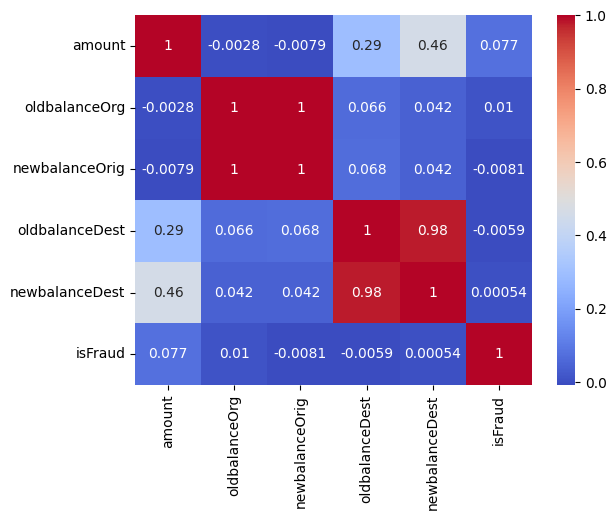

In [ ]:
correlation_matrix=df1.corr()
import seaborn as sns
print(correlation_matrix)
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm')
plt.show()

In [ ]:
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import SelectKBest, chi2

# Define y if not already defined (as it's used in both f_classif and chi2)
y = df['isFraud']

# --- ANOVA F-test for continuous numerical features ---
X_continuous_anova = df1.drop('isFraud', axis=1)
continuous_cols = X_continuous_anova.columns.tolist()

f_values, p_values = f_classif(X_continuous_anova, y)

anova_df = pd.DataFrame({
    'Feature': continuous_cols,
    'F-Score': f_values,
    'P-Value': p_values
}).sort_values(by='F-Score', ascending=False)

print("ANOVA Results (Higher F-Score = More Influence on 'isFraud'):")
print(anova_df)

# --- Chi2 Test for (encoded) categorical features ---
# Note: chi2 requires non-negative values.
# 'type' was label encoded in a previous cell, and 'step' is an integer.
# These features are available in the main 'df' dataframe.

categorical_features_chi2 = ['type', 'step'] # Using 'type' and 'step' from original 'df'
X_categorical_chi2 = df[categorical_features_chi2]

selector = SelectKBest(score_func=chi2, k=len(categorical_features_chi2)) # Select all specified categorical features
X_new_chi2 = selector.fit_transform(X_categorical_chi2, y)

# View the scores
feature_scores = pd.DataFrame({
    'Feature': categorical_features_chi2,
    'Chi2_Score': selector.scores_,
    'P_Value': selector.pvalues_
}).sort_values(by='Chi2_Score', ascending=False)

print("\nChi2 Feature Selection Results:")
print(feature_scores)


ANOVA Results (Higher F-Score = More Influence on 'isFraud'):
          Feature       F-Score        P-Value
0          amount  37640.657952   0.000000e+00
1   oldbalanceOrg    656.131724  1.054289e-144
2  newbalanceOrig    422.458368   7.168312e-94
3  oldbalanceDest    220.386451   7.463207e-50
4  newbalanceDest      1.823504   1.768967e-01

Chi2 Feature Selection Results:
  Feature     Chi2_Score  P_Value
1    step  528059.136783      0.0
0    type    2936.630692      0.0


In [ ]:

df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']


In [ ]:

features_to_drop = ['nameOrig', 'nameDest', 'isFraud', 'isFlaggedFraud']
X = df.drop(features_to_drop, axis=1)
y = df['isFraud']

print("Final feature set prepared with Expert Rules. Total features:", X.shape[1])

Final feature set prepared with Expert Rules. Total features: 9


In [ ]:
# Updating the feature set to include the new engineered features
X = df.drop(['nameOrig', 'nameDest', 'isFraud', 'isFlaggedFraud'], axis=1)
y = df['isFraud']

# Stratified split to maintain fraud ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Update Autoencoder input dimension
X_train_normal = X_train_scaled[y_train == 0]
input_dim = X_train_scaled.shape[1]
encoding_dim = 8

input_layer = Input(shape=(input_dim,))
x = Dense(32, activation="relu")(input_layer)
x = Dense(16, activation="relu")(x)
latent = Dense(encoding_dim, activation="relu")(x)
x = Dense(16, activation="relu")(latent)
x = Dense(32, activation="relu")(x)
output_layer = Dense(input_dim, activation="linear")(x)

In [ ]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'errorBalanceOrig', 'errorBalanceDest'],
      dtype='object')

In [ ]:
# Updating the feature set to include the new engineered features
X = df.drop(['nameOrig', 'nameDest', 'isFraud', 'isFlaggedFraud'], axis=1)
y = df['isFraud']

# Stratified split to maintain fraud ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Update Autoencoder input dimension
X_train_normal = X_train_scaled[y_train == 0]
input_dim = X_train_scaled.shape[1]
encoding_dim = 8

input_layer = Input(shape=(input_dim,))
x = Dense(32, activation="relu")(input_layer)
x = Dense(16, activation="relu")(x)
latent = Dense(encoding_dim, activation="relu")(x)
x = Dense(16, activation="relu")(latent)
x = Dense(32, activation="relu")(x)
output_layer = Dense(input_dim, activation="linear")(x)

In [ ]:
# Instantiate the full autoencoder model
autoencoder = Model(inputs=input_layer, outputs=output_layer)

# Instantiate the encoder-only model for feature extraction
encoder = Model(inputs=input_layer, outputs=latent)

# Compile the autoencoder with Adam optimizer and Mean Squared Error loss
autoencoder.compile(optimizer='adam', loss='mse')

print("Autoencoder and Encoder models successfully compiled.")

Autoencoder and Encoder models successfully compiled.


In [ ]:
autoencoder.fit(X_train_normal, X_train_normal, epochs=15, batch_size=512, verbose=1, validation_split=0.2)

Epoch 1/15
7944/7944 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - loss: 0.0222 - val_loss: 9.1818e-04
Epoch 2/15
7944/7944 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step - loss: 0.0017 - val_loss: 8.6668e-04
Epoch 3/15
7944/7944 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step - loss: 0.0011 - val_loss: 6.1173e-04
Epoch 4/15
7944/7944 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step - loss: 7.5966e-04 - val_loss: 0.0014
Epoch 5/15
7944/7944 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step - loss: 7.7544e-04 - val_loss: 2.0041e-04
Epoch 6/15
7944/7944 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step - loss: 7.2375e-04 - val_loss: 3.9160e-04
Epoch 7/15
7944/7944 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step - loss: 5.5273e-04 - val_loss: 0.0029
Epoch 8/15
7944/7944 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step - loss: 5.5812e-04 - val_loss: 0.0017
Epoch 9/15
7944/7944 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step - loss: 5.4269e-04 - val_loss: 8.9339e-05
Epoch 10/15
7944/7944 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step - loss: 3.7205e-04 - val_loss: 9.2876e-05
Epoch 11/15
7944/7944 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/st

In [ ]:
X_train_encoded = encoder.predict(X_train_scaled)

159066/159066 ━━━━━━━━━━━━━━━━━━━━ 70s 441us/step


In [57]:
X_test_encoded = encoder.predict(X_test_scaled)

39767/39767 ━━━━━━━━━━━━━━━━━━━━ 18s 459us/step


In [58]:

import numpy as np
X_train_final = np.hstack((X_train_scaled, X_train_encoded))
X_test_final = np.hstack((X_test_scaled, X_test_e))
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    scale_pos_weight=99,
    eval_metric='logloss',
    use_label_encoder=False
)

NameError: name 'X_test_e' is not defined

In [ ]:
model.fit(X_train_final, y_train)

In [ ]:
# --- 5. THRESHOLD TUNING ---
y_prob = model.predict_proba(X_test_final)[:, 1]

# Increasing threshold to 0.9 to ensure only high-confidence fraud is flagged
custom_threshold = 0.4
y_pred_custom = (y_prob >= custom_threshold).astype(int)

# --- 6. EVALUATION ---
print("\n--- Optimized Model Results ---")
print("threshold:",custom_threshold)
print(confusion_matrix(y_test, y_pred_custom))
print(f"Precision: {precision_score(y_test, y_pred_custom):.4f}",end=",")
print(f"Recall: {recall_score(y_test, y_pred_custom):.4f}",end=',')
print(f"F1-Score: {f1_score(y_test, y_pred_custom):.4f}",end=',')
print(f"PR-AUC: {average_precision_score(y_test, y_prob):.4f}",end=',')
from sklearn.metrics import accuracy_score
print("Accuracy:",accuracy_score(y_test,y_pred_custom))

In [59]:
import tensorflow as tf

# Save the full autoencoder model
autoencoder.save('autoencoder_model.h5')

# Save the encoder part of the model
encoder.save('encoder_model.h5')

print("Autoencoder and Encoder models saved successfully.")

Autoencoder and Encoder models saved successfully.


In [63]:
# --- 7. Load Autoencoder and Encoder Models ---
from tensorflow.keras.models import load_model
import tensorflow as tf

# Define custom objects if needed (e.g., for custom loss functions)
custom_objects = {'mse': tf.keras.losses.MeanSquaredError()}

autoencoder_loaded = load_model('autoencoder_model.h5', custom_objects=custom_objects)
encoder_loaded = load_model('encoder_model.h5', custom_objects=custom_objects)

print("Autoencoder and Encoder models loaded successfully.")

Autoencoder and Encoder models loaded successfully.


In [64]:
# --- 8. Retrain and Evaluate XGBoost Model with corrected data ---
import numpy as np

X_train_final = np.hstack((X_train_scaled, X_train_encoded))
X_test_final = np.hstack((X_test_scaled, X_test_encoded)) # Corrected variable name

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    scale_pos_weight=99,
    eval_metric='logloss',
    use_label_encoder=False
)

model.fit(X_train_final, y_train)

# --- 9. THRESHOLD TUNING --- (Copied from s-QFCwpCq9Dz to run after model.fit)
y_prob = model.predict_proba(X_test_final)[:, 1]

# Increasing threshold to 0.9 to ensure only high-confidence fraud is flagged
custom_threshold = 0.4
y_pred_custom = (y_prob >= custom_threshold).astype(int)

# --- 10. EVALUATION --- (Copied from s-QFCwpCq9Dz to run after model.fit)
print("\n--- Optimized Model Results ---")
print("threshold:",custom_threshold)
print(confusion_matrix(y_test, y_pred_custom))
print(f"Precision: {precision_score(y_test, y_pred_custom):.4f}",end=",")
print(f"Recall: {recall_score(y_test, y_pred_custom):.4f}",end=',')
print(f"F1-Score: {f1_score(y_test, y_pred_custom):.4f}",end=',')
print(f"PR-AUC: {average_precision_score(y_test, y_prob):.4f}",end=',')
from sklearn.metrics import accuracy_score
print("Accuracy:",accuracy_score(y_test,y_pred_custom))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:54:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Optimized Model Results ---
threshold: 0.4
[[1270690     191]
 [     26    1617]]
Precision: 0.8944,Recall: 0.9842,F1-Score: 0.9371,PR-AUC: 0.9919,Accuracy: 0.9998294727643644


epochs=15,batchsize=512

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.99   1270881
           1       0.04      0.92      0.08      1643

    accuracy                           0.97   1272524
   macro avg       0.52      0.95      0.53   1272524
weighted avg       1.00      0.97      0.98   1272524

ROC-AUC: 0.9919
PR-AUC: 0.6820
[[1234077   36804]
 [    125    1518]]
recall: 0.923919659160073
precision: 0.039611711288554875
accuracy: 0.9709797221899155
f1: 0.0759664706618291
roc: 0.9919036606330822
pr: 0.6819600600691728

